# 1. Descripción y contextualización del problema

1.1 ¿Cuál es el problema que se desea resolver?  
    El problema consiste en desarrollar modelos de clasificacion que sean capaces de predecir si un estudiante abandona la carrera, esta inscripto o se gradua.  

1.2 ¿Cuál es su contexto de aplicación?  
    Se puede utilizar para ayudar en algunas tomas de decisiones como:  
    - Identificar estudiantes con riesgo de abandono y ofrecerles acompanamiento, incentivos
    - Orientar la asignación de becas o beneficios, priorizando a aquellos estudiantes que tienen alta probabilidad de graduarse.  

1.3 ¿Por qué puede resultar útil aplicar Machine Learning?  
    Aplicar Machine Learning resulta util porque ayuda a capturar relaciones complejas entre multiples variables que una persona no puede identificar o le costaria mas trabajo hacerlo, ademas se puede realizar predicciones automáticas y escalables para grandes cantidades de estudiantes.  

1.4 ¿Qué se desea predecir?  
Se desea predecir el resultado academico final, si un estudiante culmina sus estudios, esta inscripto o si abandona la carrera.  

1.5  ¿Qué representa cada clase?  
    Dropout: el estudiante abandona la carrera.  
    Graduate: el estudiante finaliza exitosamente sus estudios.  
    Enrolled: el estudiante se encuentra inscripto en la carrera.  

1.6  ¿Cuál es la variable objetivo?  
    La variable objetivo es la columna "Target" que indica el resultado academico final, dropout, enrolled o Graduate

# 2. Descripción del conjunto de datos

In [1]:
#Carga del dataset
%pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo
dataset = fetch_ucirepo(id=697)
X = dataset.data.features
y = dataset.data.targets

In [2]:
# Ver dimensiones
n_instancias,n_atributos = X.shape
print("Instancias:",n_instancias)
print("Atributos:",n_atributos)

Instancias: 4424
Atributos: 36


In [3]:
#Variable Objetivo y Numero de clases
y.value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [4]:
#Tipos de variables 
X.dtypes

,0
Marital Status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance,int64
Previous qualification,int64
Previous qualification (grade),float64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64


In [5]:
# Cantidad de valores únicos por columna
X.nunique().sort_index()

,0
Admission grade,620
Age at enrollment,46
Application mode,18
Application order,8
Course,17
Curricular units 1st sem (approved),23
Curricular units 1st sem (credited),21
Curricular units 1st sem (enrolled),23
Curricular units 1st sem (evaluations),35
Curricular units 1st sem (grade),797


In [6]:
#Distribucion de clases conteo y porcentaje
dist = y.value_counts().sort_index()
dist_pct = (dist / len(y) * 100).round(2)

print("\nDistribución de clases (conteo):")
print(dist)

print("\nDistribución de clases (%):")
print(dist_pct)


Distribución de clases (conteo):
Target  
Dropout     1421
Enrolled     794
Graduate    2209
Name: count, dtype: int64

Distribución de clases (%):
Target  
Dropout     32.12
Enrolled    17.95
Graduate    49.93
Name: count, dtype: float64


In [7]:
#Existencia de datos faltantes
nulos = (
    X.isnull()
    .sum()
    .to_frame("cantidad_nulos")
)
nulos.sort_values(by="cantidad_nulos", ascending=False)



,cantidad_nulos
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


### Descripción del conjunto de datos
● Nombre del dataset: Predict Students' Dropout and Academic Success.  
● fuente: el dataset fue descargado desde UCI Machine Learning Repository – Dataset ID 697 pero pertence al programa SATDAP - Capacitação da Administração Pública under grant POCI-05-5762-FSE-000191 de Portugal.
● número de instancias: 4424  
● número de atributos: 36  
● variable objetivo: columna Target  
● número de clases: Graduate, Dropout, Enrolled  
● tipos de variables:  
    - Variables numéricas enteras (int64): la mayoría de los atributos, como estado civil, modo de aplicación, curso, calificaciones previas, ocupación de los padres, género, número de unidades curriculares, etc.  
    - Variables numéricas continuas (float64): algunas variables como Previous qualification (grade), Admission grade, Curricular units 1st sem (grade), Curricular units 2nd sem (grade), Unemployment rate, Inflation rate y GDP.  
    Todas las variables son de tipo numérico; las categóricas originales (como estado civil, género, curso, etc.) ya se encuentran codificadas como enteros.  
● distribución de las clases: la clase Dropout es del 32.12%, Enrolled es de 17.85% y Graduate del 49.93%  
● existencia o no de datos faltantes: No se observan datos faltantes en ninguna de las variables del conjunto de datos.

#  3. Analisis Exploratorio de Datos

Se deberá realizar un análisis exploratorio básico que permita comprender las principales
características del conjunto de datos.  
El estudiante deberá seleccionar aquellas que resulten relevantes para comprender su
conjunto de datos y deberá interpretar brevemente las visualizaciones obtenidas

In [8]:
#Librerias necesarias
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [9]:
#Creamos el dataframe df a partir de X e y
df = pd.concat([X, y], axis=1)

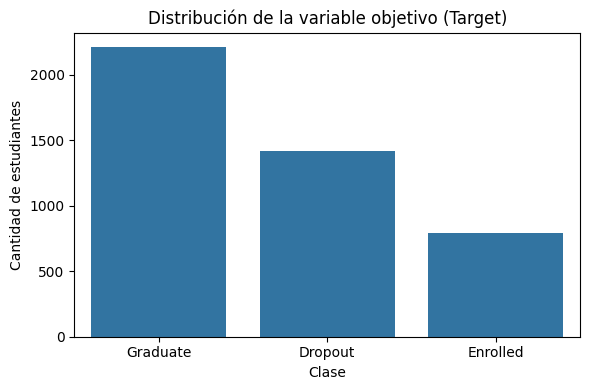

In [10]:
#Distribucion de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Target", order=["Graduate", "Dropout", "Enrolled"])
plt.title("Distribución de la variable objetivo (Target)")
plt.xlabel("Clase")
plt.ylabel("Cantidad de estudiantes")
plt.tight_layout()
plt.show()

Se observa que la clase mayoritaria es Graduate, seguida de Dropout y luego Enrolled.
EL grafico nos indica un desbalance de clases, lo cual puede afectar el entrenamiento de los modelos (tenderán a favorecer la clase mayoritaria).
Durante el modelado será importante usar métricas adecuadas (F1, matriz de confusión, etc.) y posiblemente técnicas para manejar el desbalance.

In [11]:
variables_interes = [
    "Previous qualification (grade)",
    "Admission grade",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

df[variables_interes].describe()

,Previous qualification (grade),Admission grade,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Age at enrollment,Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,10.640822,10.230206,23.265145,11.566139,1.228029,0.001969
std,13.188332,14.482001,4.843663,5.210808,7.587816,2.663850,1.382711,2.269935
min,95.000000,95.000000,0.000000,0.000000,17.000000,7.600000,-0.800000,-4.060000
25%,125.000000,117.900000,11.000000,10.750000,19.000000,9.400000,0.300000,-1.700000
50%,133.100000,126.100000,12.285714,12.200000,20.000000,11.100000,1.400000,0.320000
75%,140.000000,134.800000,13.400000,13.333333,25.000000,13.900000,2.600000,1.790000
max,190.000000,190.000000,18.875000,18.571429,70.000000,16.200000,3.700000,3.510000


- Previous qualification (grade):Calificación de la titulación previa (entre 0 y 200)  
- Admission grade:Calificación de admisión (entre 0 y 200)  
- Curricular units 1st sem (grade): Promedio de calificaciones del primer semestre (entre 0 y 20)  
- Curricular units 2nd sem (grade): Promedio de calificaciones del segundo semestre (entre 0 y 20)  
- Age at enrollment: Edad a la que se inscribio.  
- Unemployment rate: Tasa de desempleo (%)  
- Inflation rate: tasas de inflacion (%)  
- GDP: PIB

Las variables académicas (Previous qualification (grade), Admission grade, Curricular units 1st/2nd sem (grade)) presentan un amplio rango de valores, con medias de 132.6 y 126.97 para las notas previas y de admisión, respectivamente, y medias alrededor de 10.6 y 10.2 para las notas de los dos primeros semestres.En particular, las notas de los semestres muestran una distribución sesgada hacia valores bajos, con mínimos en 0, lo que sugiere la presencia de estudiantes con bajo rendimiento académico que podrían estar asociados a la clase Dropout.  
La edad al momento de la inscripción tiene una media de 23.3 años y una mediana de 20 años, indicando un perfil mayoritariamente joven, con una cola de estudiantes de mayor edad (hasta 70 años).  
Las variables contextuales (Unemployment rate, Inflation rate, GDP) reflejan distintos escenarios socioeconómicos, con tasas de desempleo entre 7.6% y 16.2%, inflación entre -0.8% y 3.7%, y crecimiento del PIB entre -4.06 y 3.51, lo que permite analizar el impacto del contexto económico en el abandono y éxito académico.

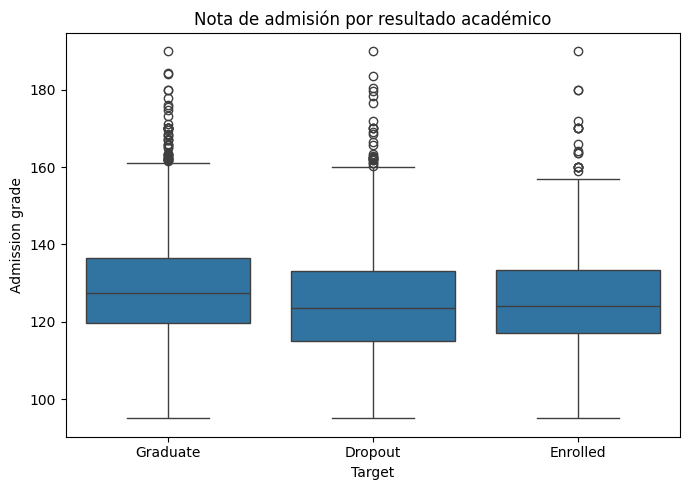

In [12]:
#Relacion entre notas academicas y target
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Target",
    y="Admission grade",
    order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Nota de admisión por resultado académico")
plt.xlabel("Target")
plt.ylabel("Admission grade")
plt.tight_layout()
plt.show()

se puede observar que los estudiantes graduados tienen en promedio notas de admision un poco mayor que los estudiantes que abandonaron la carrera. Sin embargo, la separación entre clases es moderada, las cajas se superponen bastante, por lo que la nota de admisión, por sí sola, no parece distinguir claramente entre Graduate, Dropout y Enrolled

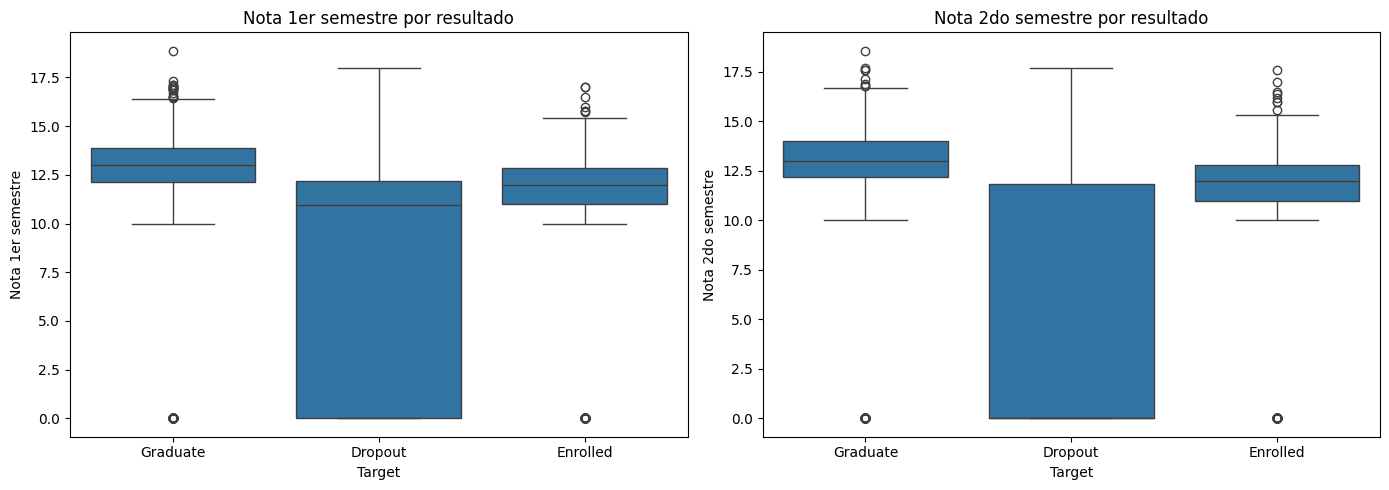

In [13]:
# Relacion entre las notas de primer y segundo semestre con el target
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (grade)",
    order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Nota 1er semestre por resultado")
plt.xlabel("Target")
plt.ylabel("Nota 1er semestre")

plt.subplot(1,2,2)
sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 2nd sem (grade)",
    order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Nota 2do semestre por resultado")
plt.xlabel("Target")
plt.ylabel("Nota 2do semestre")

plt.tight_layout()
plt.show()

Con estos graficos de caja de las distribuciones de las notas durante el primer y segundo semestre para cada categoria del target.  
En ambos periodos los estudiantes de la clase graduate tienen la mediana mas elevada, seguida de enrolled y por ultimo la clase de Dropout.  
Dentro de la clase dropout se observan numerosos valores iguales o cercanos a cero, esto podria indicar un bajo rendimiento academico, en cambio para las clases enrolled y graduate las notas se encuentran mas concentradas en valores medios y altos

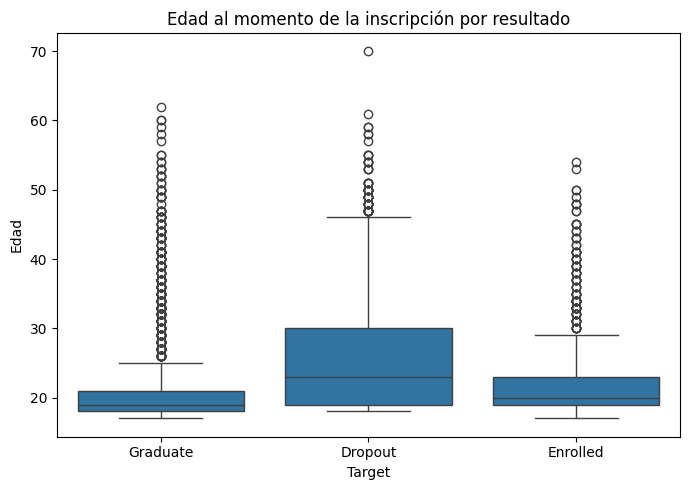

In [14]:
# Edad al momento de la inscripción vs resultado
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Target",
    y="Age at enrollment",
    order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Edad al momento de la inscripción por resultado")
plt.xlabel("Target")
plt.ylabel("Edad")
plt.tight_layout()
plt.show()

los Dropout tienden a ser un poco más viejos que los Graduate, esto puede indicar que la edad influye muy poco en la probabilidad de abandono.


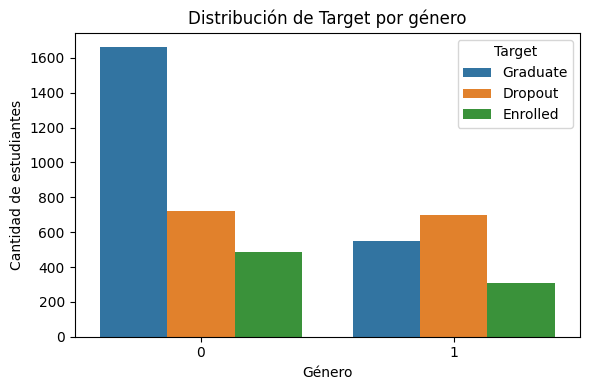

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Gender",
    hue="Target",
    hue_order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Distribución de Target por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de estudiantes")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

Se puede observar que para el caso de los hombres, la proporcion de abandono es mayor que el caso de las mujeres

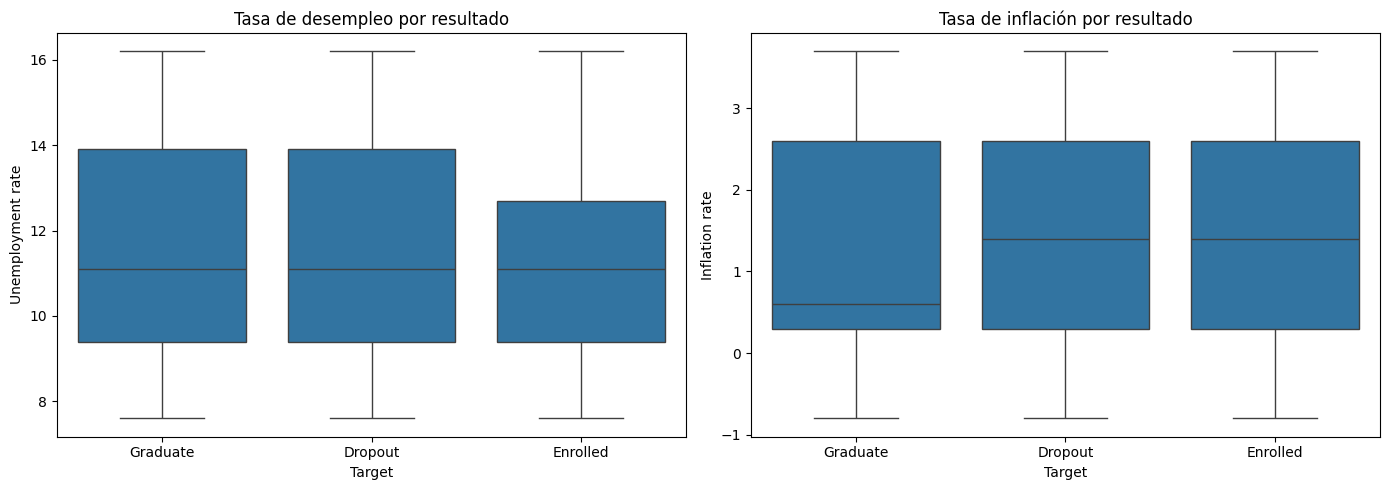

In [16]:
#Tasa de desempleo e inflación vs resultado

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(
    data=df,
    x="Target",
    y="Unemployment rate",
    order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Tasa de desempleo por resultado")
plt.xlabel("Target")
plt.ylabel("Unemployment rate")

plt.subplot(1,2,2)
sns.boxplot(
    data=df,
    x="Target",
    y="Inflation rate",
    order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Tasa de inflación por resultado")
plt.xlabel("Target")
plt.ylabel("Inflation rate")

plt.tight_layout()
plt.show()

para el caso de la tasa de desempleo no hay practicamente diferencias, en el caso de tasa de inflacion vemos que la mediana de la inflacion para los que abandonan la carrera es mayor que la de los graduados. 

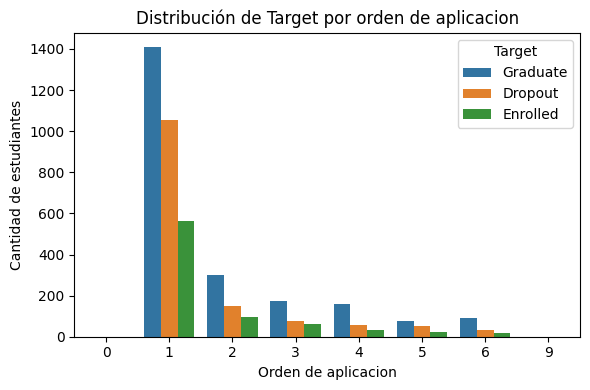

In [17]:
#orden de aplicacion 0 primera opcion favorito 9 ultima opcion
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Application order",
    hue="Target",
    hue_order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Distribución de Target por orden de aplicacion")
plt.xlabel("Orden de aplicacion")
plt.ylabel("Cantidad de estudiantes")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

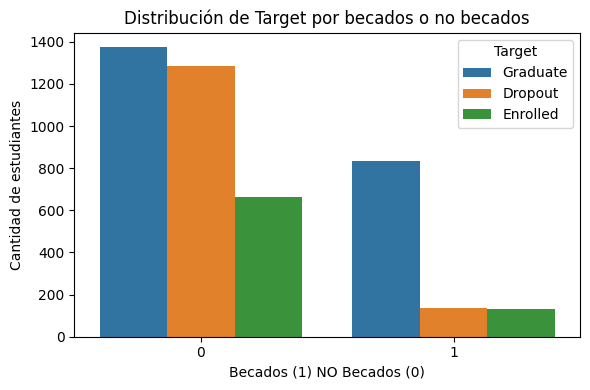

In [18]:
# comparacion de los becados
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Scholarship holder",
    hue="Target",
    hue_order=["Graduate", "Dropout", "Enrolled"]
)
plt.title("Distribución de Target por becados o no becados")
plt.xlabel("Becados (1) NO Becados (0)")
plt.ylabel("Cantidad de estudiantes")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

Podemos observar que para la categoria de becados es mayor la diferencia entre los graduados y los que abandonan

# 4. Preprocesamiento de los datos

## Busqueda de duplicados

In [19]:
# Duplicados exactos

print("\nFilas duplicadas exactas:", df.duplicated().sum())


Filas duplicadas exactas: 0


No existen duplicados y anteriormente ya vimos que no hay valores faltantes, por lo que no es necesario aplicar tecnicas de imputacion de datos

## Identificacion de las variables
En las variables numericas hay dos grupos:  
Continuas: calificaciones, edad, tasa de desempleo, inflación y gdp.  
Recuentos discretos: cantidad de unidades curriculares acreditadas, inscritas, evaluadas o aprobadas.
Aunque los recuentos sean enteros, puede ser razonable estandarizarlos junto con las variables continuas para modelos sensibles a escala  

Para las variables binarias no hace falta aplicar one hot encoding, ya se encuentran codificadas, en cambio a las variables categoricas si aplicaremos one hot encoding

In [20]:
#Identificar correctamente las variables

numericas = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

categoricas = [
    "Marital Status",
    "Application mode",
    "Application order",
    "Course",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

binarias = [
    "Daytime/evening attendance",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

## Codificacion de variables categoricas
Las variables categóricas se encuentran representadas mediante numeros enteros. Sin embargo, dichos numeros no implican una relación de orden ni una distancia cuantitativa entre categorías. Por ejemplo, un numero mayor no representa un curso “mejor” ni más cercano a otro. Por esta razón, se utiliza One-Hot Encoding, que crea una variable indicadora para cada categoría y evita introducir relaciones ordinales.

In [21]:

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

## Estandarizacion y normalizacion
Las variables numéricas presentan escalas muy diferentes. Por ello, se aplica estandarización mediante StandardScaler a las variables numéricas. Esto evita que los atributos con escalas mayores tengan una influencia desproporcionada en algoritmos sensibles a la magnitud de las variables, como Regresión Logística, KNN y SVM.  
Se evaluó la normalización Min–Max, pero no se aplicó junto con la estandarización, ya que ambas transformaciones cumplen el objetivo de ajustar escalas y aplicarlas simultáneamente sería redundante. Además, la normalización Min–Max es más sensible a valores extremos.  

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


## Pipeline de preprocesamiento

In [23]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), numericas),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), categoricas),
        ("binarias", "passthrough", binarias)
    ],
    remainder="drop"
)

## Tratamiento del desbalance
Para tratar el desbalance en la variable target se realizara:  
- División estratificada (stratify=y) para que train y test tengan aproximadamente las proporciones de clases y asi evitar que el desbalance se agrave durante el split.  
- Entrenar con class_weight="balanced" en los modelos que lo permitan.  
- Evaluar con métricas por clase: precision, recall, F1-macro y matriz de confusión.

# 5. Protocolo experimental

## Training/Test split

In [24]:
from sklearn.model_selection import train_test_split


# Separación training/test: 80% para el training y 20% para evaluación final
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)

print("\nDistribución total:")
print(y.value_counts())
print((y.value_counts(normalize=True) * 100).round(2))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución en test:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Tamaño de X_train: (3539, 36)
Tamaño de X_test: (885, 36)

Distribución total:
Target  
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target  
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

Distribución en entrenamiento:
Target  
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64
Target  
Graduate    49.93
Dropout     32.13
Enrolled    17.94
Name: proportion, dtype: float64

Distribución en test:
Target  
Graduate    442
Dropout     284
Enrolled    159
Name: count, dtype: int64
Target  
Graduate    49.94
Dropout     32.09
Enrolled    17.97
Name: proportion, dtype: float64


In [25]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

El conjunto de datos se dividio en un conjunto de entrenamiento y un conjunto de prueba mediante la función train_test_split. Se utilizó una proporción de 80% para entrenamiento y 20% para prueba.

Debido a que la variable objetivo presenta un desbalance, se aplicó estratificación mediante el parámetro stratify=y. De este modo, se preservaron proporciones similares de cada clase tanto en el conjunto de entrenamiento como en el conjunto de prueba.

Para la selección de modelos y el ajuste de hiperparámetros se utilizara validación cruzada estratificada de 5 particiones (StratifiedKFold) exclusivamente sobre el conjunto de entrenamiento. 

El conjunto de prueba se mantuvo completamente aislado durante el desarrollo experimental. La codificación de variables categóricas, estandarización, selección de atributos y ajuste de hiperparámetros se realizaran únicamente con los datos de entrenamiento. Estas transformaciones se implementaran mediante un Pipeline, que garantiza que en cada fold los parámetros de preprocesamiento se ajusten solo con la partición de entrenamiento correspondiente. Finalmente, el conjunto de prueba se utilizara una única vez para evaluar el modelo final seleccionado. Esto reduce el riesgo de fuga de información y evita obtener estimaciones artificialmente optimistas del desempeño.



# 6. Modelos de Machine Learning

## Regresion Logistica
La Regresión Logística utilizamos como modelo de referencia,estima la probabilidad de pertenecer a cada clase y permite observar si un modelo lineal ya separa razonablemente Dropout, Enrolled y Graduate. Scikit-learn admite clasificación multiclase con solver lbfgs,

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_rl= Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])
pipeline_rl.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Previous qualification '
                                                   '(grade)',
                                                   'Admission grade',
                                                   'Age at enrollment',
                                                   'Curricular units 1st sem '
                                                   '(credited)',
                                                   'Curricular units 1st sem '
                                                   '(enrolled)',
                                                   'Curricular units 1st sem '
                                                   '(evaluations)',
                                                   'Curricular units 1st sem '
                                                   '(approved)',
                                                   'Curricular units 1st sem '
                                                   '(grade)',
                                                   'Curric...
                                                   "Mother's qualification",
                                                   "Father's qualification",
                                                   "Mother's occupation",
                                                   "Father's occupation"]),
                                                 ('binarias', 'passthrough',
                                                  ['Daytime/evening attendance',
                                                   'Displaced',
                                                   'Educational special needs',
                                                   'Debtor',
                                                   'Tuition fees up to date',
                                                   'Gender',
                                                   'Scholarship holder',
                                                   'International'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

Parámetros iniciales  
solver="lbfgs": adecuado para clasificación multiclase y problemas de tamaño moderado.  
max_iter=3000: aumenta el máximo de iteraciones para ayudar a la convergencia tras el One-Hot Encoding.  
class_weight="balanced": pondera más los errores de las clases menos frecuentes, especialmente Enrolled.  
random_state=42: permite reproducir el experimento.

## Support Vector Machines
SVM busca una frontera que separe las clases maximizando el margen entre ellas.

In [27]:
from sklearn.svm import SVC
pipeline_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

pipeline_svm.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Previous qualification '
                                                   '(grade)',
                                                   'Admission grade',
                                                   'Age at enrollment',
                                                   'Curricular units 1st sem '
                                                   '(credited)',
                                                   'Curricular units 1st sem '
                                                   '(enrolled)',
                                                   'Curricular units 1st sem '
                                                   '(evaluations)',
                                                   'Curricular units 1st sem '
                                                   '(approved)',
                                                   'Curricular units 1st sem '
                                                   '(grade)',
                                                   'Curric...
                                                   'Nacionality',
                                                   "Mother's qualification",
                                                   "Father's qualification",
                                                   "Mother's occupation",
                                                   "Father's occupation"]),
                                                 ('binarias', 'passthrough',
                                                  ['Daytime/evening attendance',
                                                   'Displaced',
                                                   'Educational special needs',
                                                   'Debtor',
                                                   'Tuition fees up to date',
                                                   'Gender',
                                                   'Scholarship holder',
                                                   'International'])])),
                ('model',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

Parámetros iniciales  
kernel="rbf": permite encontrar fronteras no lineales; es adecuado como punto de partida.
C=1.0: valor inicial estándar que representa un equilibrio entre margen amplio y penalización de errores.  
gamma="scale": ajusta automáticamente la escala de influencia de las observaciones según la variabilidad de los datos.  
class_weight="balanced": compensa el desbalance moderado de la variable objetivo 
probability=True: habilita estimación de probabilidades; puede resultar útil más adelante para curvas o análisis de confianza

## Random Forest
Como sistema ensamblado se eligio Random Forest que entrena múltiples árboles de decisión sobre muestras aleatorias de los datos y subconjuntos de atributos. Luego combina sus predicciones mediante votación. Al promediar muchos árboles, reduce la varianza de un árbol individual y suele capturar interacciones y patrones no lineales

In [28]:
from sklearn.ensemble import RandomForestClassifier
pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Previous qualification '
                                                   '(grade)',
                                                   'Admission grade',
                                                   'Age at enrollment',
                                                   'Curricular units 1st sem '
                                                   '(credited)',
                                                   'Curricular units 1st sem '
                                                   '(enrolled)',
                                                   'Curricular units 1st sem '
                                                   '(evaluations)',
                                                   'Curricular units 1st sem '
                                                   '(approved)',
                                                   'Curricular units 1st sem '
                                                   '(grade)',
                                                   'Curric...
                                                   "Mother's qualification",
                                                   "Father's qualification",
                                                   "Mother's occupation",
                                                   "Father's occupation"]),
                                                 ('binarias', 'passthrough',
                                                  ['Daytime/evening attendance',
                                                   'Displaced',
                                                   'Educational special needs',
                                                   'Debtor',
                                                   'Tuition fees up to date',
                                                   'Gender',
                                                   'Scholarship holder',
                                                   'International'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

Parámetros iniciales  
n_estimators=300: utiliza 300 árboles para obtener predicciones más estables que un único árbol.  
max_depth=None: inicialmente permite árboles completos; más adelante se estudiará limitar la profundidad para controlar el sobreajuste.
min_samples_split=2 y min_samples_leaf=1: configuración inicial estándar.  
max_features="sqrt": cada división considera una cantidad aleatoria de atributos equivalente a la raíz cuadrada del total, lo que aumenta la diversidad de los árboles.  
class_weight="balanced": ajusta los pesos según la frecuencia de las clases.  
n_jobs=-1: utiliza los núcleos disponibles para acelerar el entrenamiento.  
random_state=42: asegura reproducibilidad.  

Aunque Random Forest no necesita estandarización para tomar decisiones, se mantiene dentro del mismo Pipeline para aplicar de forma consistente la codificación de categorías. El escalado no perjudica el modelo, aunque no sea esencial para él.

## Red Neuronal MLPClassifier
La red neuronal utilizada será un perceptrón multicapa (MLPClassifier). Posee una capa de entrada, una o más capas ocultas y una capa de salida que genera una predicción para las tres clases. Puede aprender relaciones no lineales complejas entre variables académicas, sociodemográficas y económicas.

In [31]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

pipeline_mlp = Pipeline([
    ('preprocessor', preprocessor),  # Agregar aquí
    ('mlp', MLPClassifier(max_iter=500, random_state=42))
])

# Primero codificar y
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Entrenar con datos codificados
pipeline_mlp.fit(X_train, y_train_encoded)


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Previous qualification '
                                                   '(grade)',
                                                   'Admission grade',
                                                   'Age at enrollment',
                                                   'Curricular units 1st sem '
                                                   '(credited)',
                                                   'Curricular units 1st sem '
                                                   '(enrolled)',
                                                   'Curricular units 1st sem '
                                                   '(evaluations)',
                                                   'Curricular units 1st sem '
                                                   '(approved)',
                                                   'Curricular units 1st sem '
                                                   '(grade)',
                                                   'Curric...
                                                   'Previous qualification',
                                                   'Nacionality',
                                                   "Mother's qualification",
                                                   "Father's qualification",
                                                   "Mother's occupation",
                                                   "Father's occupation"]),
                                                 ('binarias', 'passthrough',
                                                  ['Daytime/evening attendance',
                                                   'Displaced',
                                                   'Educational special needs',
                                                   'Debtor',
                                                   'Tuition fees up to date',
                                                   'Gender',
                                                   'Scholarship holder',
                                                   'International'])])),
                ('mlp', MLPClassifier(max_iter=500, random_state=42))])

Parámetros iniciales  
hidden_layer_sizes=(64,): una capa oculta de 64 neuronas. Es una arquitectura inicial de complejidad moderada para un dataset de aproximadamente 3.500 ejemplos de entrenamiento.  
activation="relu": función eficiente para modelar patrones no lineales.  
solver="adam": optimizador adaptativo adecuado para este tipo de problema.  
alpha=0.0001: regularización L2 para limitar pesos demasiado grandes y reducir sobreajuste.  
learning_rate_init=0.001: tasa de aprendizaje inicial estándar para adam.  
batch_size=32: tamaño de lote habitual que equilibra estabilidad del gradiente y eficiencia.  
max_iter=1000: máximo de iteraciones para favorecer convergencia.  
early_stopping=True: detiene el entrenamiento si no mejora la validación interna.  
validation_fraction=0.15: reserva el 15% de X_train para controlar la mejora durante el entrenamiento de la red.  
n_iter_no_change=30: espera 30 iteraciones sin mejora antes de detenerse.  
random_state=42: garantiza reproducibilidad.  

## Pruebas iniciales

In [32]:
modelos = ["regresion logistica","support vector machine","random forest","redes neuronales"]
pipelines = [pipeline_rl,pipeline_svm,pipeline_rf,pipeline_mlp]

from sklearn.model_selection import cross_validate
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro"
}
resultados_baseline = []

for i, pipeline in enumerate(pipelines):

    cv_result = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    resultados_baseline.append({
        "Modelo": modelos[i],
        "Accuracy media CV": cv_result["test_accuracy"].mean(),
        "Accuracy std CV": cv_result["test_accuracy"].std(),
        "F1-macro media CV": cv_result["test_f1_macro"].mean(),
        "F1-macro std CV": cv_result["test_f1_macro"].std(),
        "Precision-macro media CV": cv_result["test_precision_macro"].mean(),
        "Recall-macro media CV": cv_result["test_recall_macro"].mean()
    })
tabla_baseline = (
    pd.DataFrame(resultados_baseline)
      .sort_values("F1-macro media CV", ascending=False)
      .reset_index(drop=True)
)
display(tabla_baseline.round(4))

,Modelo,Accuracy media CV,Accuracy std CV,F1-macro media CV,F1-macro std CV,Precision-macro media CV,Recall-macro media CV
0,support vector machine,0.7513,0.0131,0.7107,0.0150,0.7170,0.7177
1,regresion logistica,0.7485,0.0127,0.7065,0.0144,0.7083,0.7137
2,random forest,0.7697,0.0124,0.6767,0.0191,0.7284,0.6676
3,redes neuronales,0.7414,0.0136,0.6760,0.0184,0.6821,0.6726


# 7. Ajuste de hiperparámetros

In [33]:
dos_mejores_modelos = tabla_baseline.head(2)["Modelo"].tolist()

print("Los dos modelos seleccionados para tuning son:")
for modelo in dos_mejores_modelos:
    print("-", modelo)

Los dos modelos seleccionados para tuning son:
- support vector machine
- regresion logistica


In [34]:
scoring = "f1_macro"

utilizamos f1_macro porque calcula el F1-score de Dropout, Enrolled y Graduate, y luego obtiene una media no ponderada. Así, cada clase tiene el mismo peso al seleccionar la configuración, incluso Enrolled, que es la clase minoritaria.

## Ajuste de Regresion logistica

In [35]:
from sklearn.model_selection import GridSearchCV
pipeline_rl_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

param_grid_rl = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_rl = GridSearchCV(
    estimator=pipeline_rl_tuning,
    param_grid=param_grid_rl,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_rl.fit(X_train, y_train)

print("Mejores hiperparámetros para Regresión Logística:")
print(grid_rl.best_params_)

print("\nMejor F1-macro promedio en CV:")
print(round(grid_rl.best_score_, 4))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mejores hiperparámetros para Regresión Logística:
{'model__C': 0.1}

Mejor F1-macro promedio en CV:
0.7161


## Ajuste de Support Vector Machine

In [36]:
pipeline_svm_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        class_weight="balanced",
        probability=False,
        random_state=42
    ))
])

param_grid_svm = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.001, 0.01, 0.1]
    }
]

grid_svm = GridSearchCV(
    estimator=pipeline_svm_tuning,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_svm.fit(X_train, y_train)

print("Mejores hiperparámetros para SVM:")
print(grid_svm.best_params_)

print("\nMejor F1-macro promedio en CV:")
print(round(grid_svm.best_score_, 4))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mejores hiperparámetros para SVM:
{'model__C': 100, 'model__gamma': 0.001, 'model__kernel': 'rbf'}

Mejor F1-macro promedio en CV:
0.7235


# 8. Evaluación de los modelos

El modelo que obtuvo la mejor puntuacion fue Support Vector Machine, por lo que evaluaremos con el dataset de prueba

In [37]:
# Modelo con los parametros encontrados por GridSearchCV
mejor_modelo = grid_svm.best_estimator_

# Predicciones sobre el conjunto de test
y_pred_test = mejor_modelo.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,classification_report
orden_clases = ["Dropout", "Enrolled", "Graduate"]

# Métricas globales
accuracy_test = accuracy_score(y_test, y_pred_test)

precision_macro_test = precision_score(
    y_test,
    y_pred_test,
    average="macro",
    zero_division=0
)

recall_macro_test = recall_score(
    y_test,
    y_pred_test,
    average="macro",
    zero_division=0
)

f1_macro_test = f1_score(
    y_test,
    y_pred_test,
    average="macro",
    zero_division=0
)

f1_weighted_test = f1_score(
    y_test,
    y_pred_test,
    average="weighted",
    zero_division=0
)

print("MÉTRICAS GLOBALES — SVM AJUSTADO EN TEST")
print(f"Accuracy:        {accuracy_test:.4f}")
print(f"Precision macro: {precision_macro_test:.4f}")
print(f"Recall macro:    {recall_macro_test:.4f}")
print(f"F1-macro:        {f1_macro_test:.4f}")
print(f"F1-weighted:     {f1_weighted_test:.4f}")

print("\nREPORTE POR CLASE")
print(
    classification_report(
        y_test,
        y_pred_test,
        labels=orden_clases,
        digits=4,
        zero_division=0
    )
)

MÉTRICAS GLOBALES — SVM AJUSTADO EN TEST
Accuracy:        0.7469
Precision macro: 0.7178
Recall macro:    0.7190
F1-macro:        0.7080
F1-weighted:     0.7592

REPORTE POR CLASE
              precision    recall  f1-score   support

     Dropout     0.8522    0.6901    0.7626       284
    Enrolled     0.4310    0.6478    0.5176       159
    Graduate     0.8702    0.8190    0.8438       442

    accuracy                         0.7469       885
   macro avg     0.7178    0.7190    0.7080       885
weighted avg     0.7855    0.7469    0.7592       885



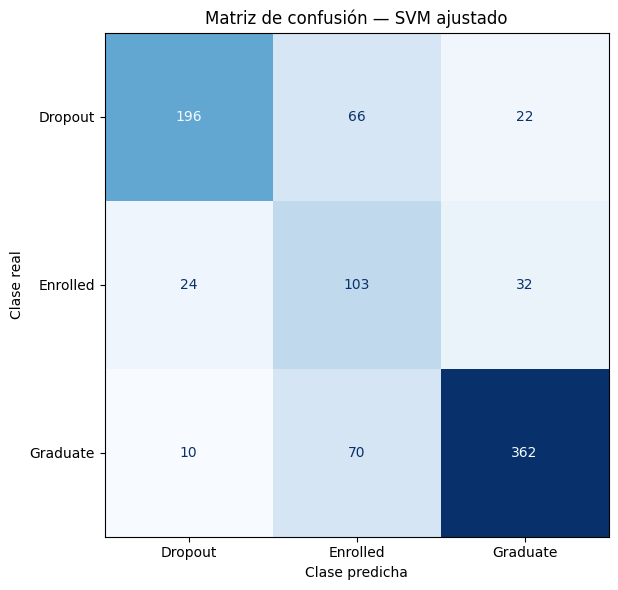

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz absoluta
matriz = confusion_matrix(
    y_test,
    y_pred_test,
    labels=orden_clases
)

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=orden_clases
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Matriz de confusión — SVM ajustado")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

# 9. Comparación de los modelos

Abajo una tabla comparativa de modelos mediante validación cruzada estratificada de cinco folds sobre el training set

| Modelo                  | Accuracy media CV | F1-macro media CV | Precision-macro media CV | Recall-macro media CV |
|-------------------------|-------------------|-------------------|--------------------------|-----------------------|
| Support Vector Machine  | 0,7513            | 0,7107            | 0,7170                   | 0,7177                |
| Regresión Logística     | 0,7485            | 0,7065            | 0,7083                   | 0,7137                |
| Random Forest           | 0,7697            | 0,6767            | 0,7284                   | 0,6676                |
| Redes Neuronales        | 0,7414            | 0,6760            | 0,6821                   | 0,6726                |

Aunque Random Forest obtuvo la mayor accuracy promedio (0,7697), Support Vector Machine obtuvo el mayor F1-macro (0,7107) y el mayor recall macro (0,7177). Dado que el problema presenta tres clases con frecuencias diferentes, se priorizó F1-macro como métrica de selección, ya que asigna la misma importancia a Dropout, Enrolled y Graduate. Por este motivo, SVM y Regresión Logística fueron seleccionados para la búsqueda de hiperparámetros.

# 10. Discusión de resultados

Los resultados nos muestran que la selección del mejor modelo no debe basarse solamente en accuracy. Durante la comparación , Random Forest alcanzó la mayor accuracy promedio (0,7697), pero Support Vector Machine obtuvo el mayor F1-macro (0,7107) y el mayor recall macro (0,7177). Esto indica que SVM presentó un rendimiento más equilibrado entre las clases Dropout, Enrolled y Graduate.  

Luego del ajuste de hiperparámetros, Support Vector Machine obtuvo un F1-macro promedio de 0,7235 en validación cruzada, superando a Regresión Logística, que alcanzó 0,7161. En consecuencia, SVM fue seleccionado como modelo final. En el conjunto de prueba, mantenido aislado durante el entrenamiento y el tuning, SVM obtuvo una accuracy de 0,7469, precision macro de 0,7178, recall macro de 0,7190 y F1-macro de 0,7080.  

La diferencia entre el F1-macro de validación cruzada (0,7235) y el obtenido en test (0,7080) fue de 0,0155. Esta variación es moderada y sugiere que el rendimiento del modelo se mantiene relativamente estable en datos no vistos, sin evidencia marcada de sobreajuste para esta partición  

Identificar correctamente la clase Dropout es especialmente relevante, ya que permitiría priorizar acciones de apoyo para estudiantes con riesgo de abandono. Por este motivo, resulta importante analizar el recall, precision y F1-score de esta clase, y no solamente la proporción global de aciertos. F1-macro fue utilizado como métrica principal porque asigna la misma importancia a las tres clases, evitando que un buen rendimiento sobre Graduate oculte un desempeño menor sobre Dropout o Enrolled.  

El desempeño obtenido debe interpretarse considerando las características del dataset. Las variables vinculadas con el rendimiento del primer y segundo semestre contienen información muy relacionada con el resultado académico final, lo que contribuye a la capacidad predictiva de los modelos. Por esta razón, el modelo es más apropiado como herramienta de alerta temprana luego de contar con información sobre el desempeño inicial del estudiante, y no como predictor exclusivo al momento de la inscripción. El dataset se formula originalmente como una tarea multiclase con Dropout, Enrolled y Graduate.  



# 11. Conclusiones

Con el presente trabajo se abordó la predicción de la situación académica de estudiantes en tres categorías: Dropout, Enrolled y Graduate, mediante cuatro modelos de Machine Learning.

Aunque Random Forest obtuvo la mayor accuracy inicial (0,7697), SVM presentó un mejor equilibrio entre las distintas clases, alcanzando el mayor F1-macro. Tras el ajuste de hiperparámetros, SVM obtuvo un F1-macro de 0,7235 en validación cruzada y fue seleccionado como modelo final. En el conjunto de prueba alcanzó un F1-macro de 0,7080 y una accuracy de 0,7469, mostrando un rendimiento relativamente estable y sin señales de sobreajuste.

El preprocesamiento, la validación estratificada, la ponderación de clases y el ajuste de hiperparámetros fueron elementos importantes para mejorar el desempeño, especialmente en SVM y Regresión Logística. Sin embargo, el estudio presenta limitaciones relacionadas con el tamaño y desbalance del dataset, así como con el uso de variables correspondientes a los primeros semestres, por lo que debe considerarse como una herramienta de alerta temprana y no como una predicción disponible desde el ingreso.

Como trabajo futuro, sería interesante evaluar modelos utilizando únicamente información disponible antes del inicio de la carrera, aplicar técnicas adicionales de balanceo, probar otros algoritmos de ensamble y realizar validaciones temporales o externas. 



# 12. Referencias Bibliograficas

- V. Realinho, J. Machado, L. Baptista and M. V. Martins, “Predict students’ dropout and academic success,” UCI Machine Learning Repository, Dataset 697, 2021. [Online]. Available:
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
. Accessed: Sep. 28, 2026.


- M. V. Martins, D. Tolledo, J. Machado, L. M. T. Baptista and V. Realinho, “Early prediction of student’s performance in higher education: A case study,” in Trends and Applications in Information Systems and Technologies, vol. 1, Advances in Intelligent Systems and Computing. Cham, Switzerland: Springer, 2021, doi: 10.1007/978-3-030-72657-7_16.

- D. Andrade-Girón, J. Sandivar-Rosas, W. Marín-Rodriguez, E. Susanibar-Ramirez, E. Toro-Dextre and A. Ausejo-Sanchez, “Predicting student dropout based on machine learning and deep learning: A systematic review,” EAI Endorsed Transactions on Scalable Information Systems, vol. 10, no. 5, 2023, doi: 10.4108/eetsis.3586.  

- D. M. W. Powers, “Evaluation: From precision, recall and F-measure to ROC, informedness, markedness and correlation,” Journal of Machine Learning Technologies, vol. 2, no. 1, pp. 37–63, 2011.

- scikit-learn developers, “MLPClassifier,” scikit-learn documentation, 2026. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html. [Accessed: Sep. 28, 2026]  

- scikit-learn developers, “1.4. Support Vector Machines,” scikit-learn documentation, 2026. [Online]. Available: https://scikit-learn.org/stable/modules/svm.html. [Accessed: Sep. 28, 2026].